In [29]:
#Task 1:Dataset Preparation

In [30]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [31]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [32]:
print(X.shape)

(569, 30)


In [33]:
print(list(data.feature_names))
print(list(data.target_names))

[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]
[np.str_('malignant'), np.str_('benign')]


In [34]:
df = pd.concat([X, y ],axis = 1)
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [35]:
print("Missing Values:\n", X.isnull().sum())
if X.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    X = X.dropna()
    print("Missing values handled by dropping rows.")

Missing Values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
No missing values found.


In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [37]:
print(X_scaled_df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           


Class distribution (0: malignant, 1:benign):
1    0.627417
0    0.372583
Name: proportion, dtype: float64


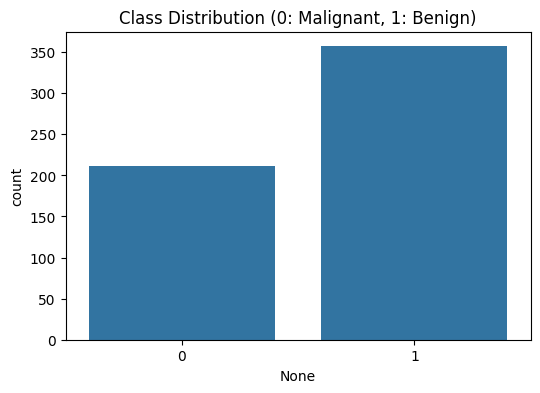

In [38]:
print("\nClass distribution (0: malignant, 1:benign):")
print(y.value_counts(normalize=True))
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution (0: Malignant, 1: Benign)")
plt.show()

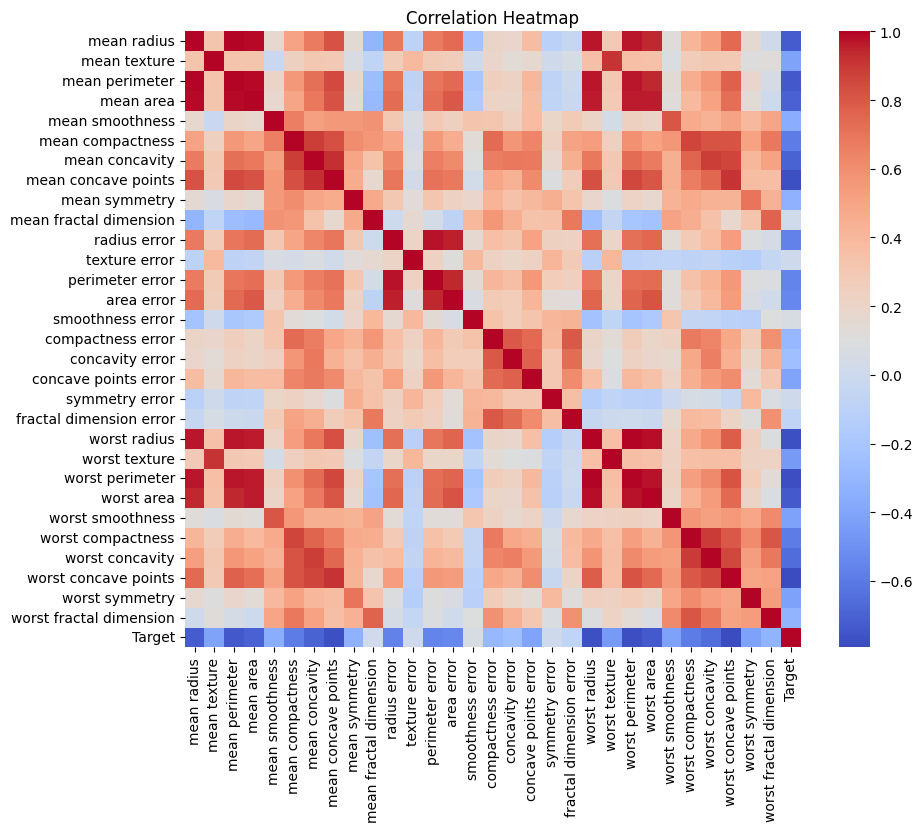

In [39]:
data_temp = X.copy()
data_temp['Target'] = y
corr_matrix = data_temp.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation Heatmap")
plt.show()

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 455, Testing samples: 114


In [41]:
#Task 2: Classification Models
#Task 2A: Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
print("Coefficients:", model_lr.coef_)
print("Intercept:",model_lr.intercept_)

Coefficients: [[ 1.8416563   0.11604855 -0.1547918   0.00543273 -0.0743871  -0.34630885
  -0.47931489 -0.20711105 -0.11122079 -0.02251289  0.0590639   0.93265271
   0.0940304  -0.0914276  -0.00706797 -0.06780586 -0.09509508 -0.02644827
  -0.02628767 -0.00589681  1.91021386 -0.35314278 -0.10729537 -0.03094047
  -0.13131502 -1.03444074 -1.27978192 -0.37990809 -0.35917677 -0.09721841]]
Intercept: [0.36142425]


In [43]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, roc_auc_score, roc_curve)
y_pred_lr = model_lr.predict(X_test)
print("Logistic Regression Evaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.2f}")
print(f"F1 Score: {f1_score(y_test,y_pred_lr):.2f}")
print(f"ROC AUC: {roc_auc_score(y_test,model_lr.predict_proba(X_test)[:, 1]):.2f}")

Logistic Regression Evaluation Metrics:
Accuracy: 0.96
Precision: 0.95
Recall: 0.99
F1 Score: 0.97
ROC AUC: 1.00


In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [45]:
model_lr_pca = LogisticRegression().fit(X_train_pca, y_train)

In [46]:
x_min, x_max = X_test_pca[:, 0].min() - 1,X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1,X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
Z = model_lr_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

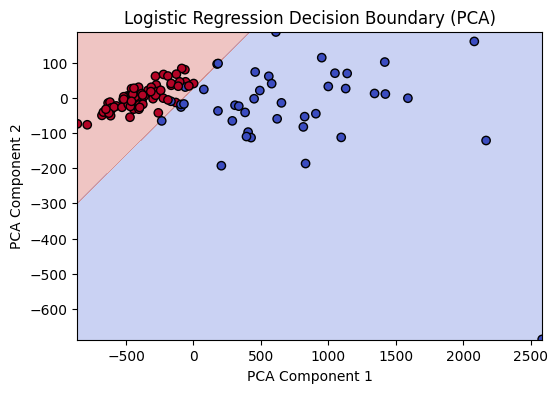

In [47]:
plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm',edgecolors='k')
plt.title("Logistic Regression Decision Boundary (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

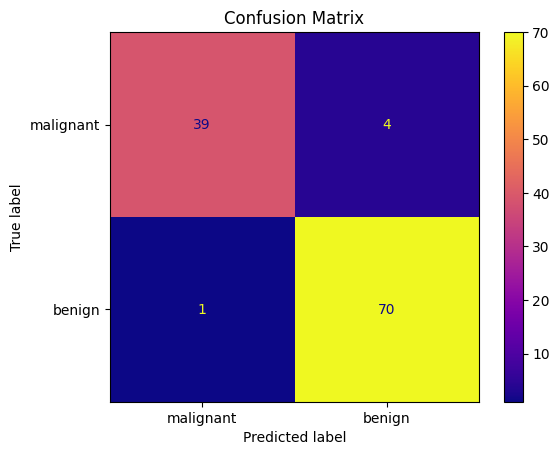

In [48]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion Matrix")
plt.show()

In [49]:
#Task 2B: K-Nearest Neighbors

In [50]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
y_pred_knn = model_knn.predict(X_test)
print("\nKNN Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.2f}")
print(f"F1 Score: {f1_score(y_test,y_pred_knn):.2f}")
print(f"ROC AUC: {roc_auc_score(y_test,model_knn.predict_proba(X_test)[:, 1]):.2f}")


KNN Metrics:
Accuracy: 0.96
Precision: 0.93
Recall: 1.00
F1 Score: 0.97
ROC AUC: 1.00


In [52]:
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [53]:
model_knn_pca = KNeighborsClassifier(n_neighbors=5).fit(X_train_pca, y_train)

In [54]:
x_min, x_max = X_test_pca[:, 0].min() - 1,X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1,X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.3), np.arange(y_min, y_max, 0.3))
Z = model_knn_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

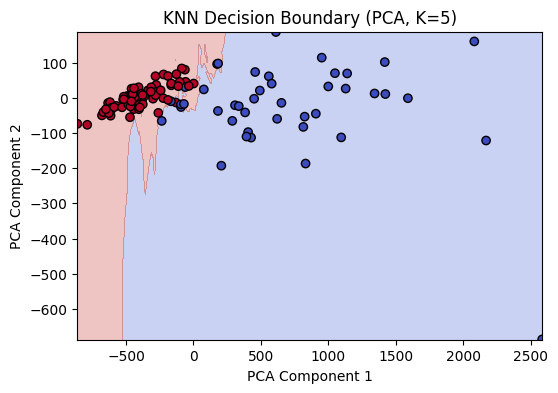

In [55]:
plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm',edgecolors='k')
plt.title("KNN Decision Boundary (PCA, K=5)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

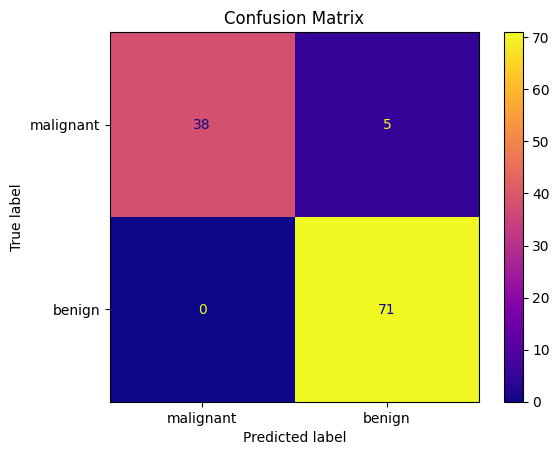

In [56]:
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion Matrix")
plt.show()

In [57]:
for k in [1, 5, 10]:
  model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
  y_pred_knn = model_knn.predict(X_test)
  print(f"KNN (K={k}) Metrics:")
  print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}, F1: {f1_score(y_test, y_pred_knn):.2f}")

KNN (K=1) Metrics:
Accuracy: 0.93, F1: 0.95
KNN (K=5) Metrics:
Accuracy: 0.96, F1: 0.97
KNN (K=10) Metrics:
Accuracy: 0.97, F1: 0.98


In [58]:
#Task 2C: Support Vector Machines

In [60]:
from sklearn.svm import SVC
for kernel in ['linear', 'rbf']:
  model_svm = SVC(kernel=kernel, probability=True, random_state=42)
  model_svm.fit(X_train, y_train)
  print(f"\n SVM ({kernel}) Support Vectors:", len(model_svm.support_vectors_))


 SVM (linear) Support Vectors: 51

 SVM (rbf) Support Vectors: 131



SVM (linear) Metrics:
Accuracy: 0.96
Precision: 0.95
Recall: 0.99
F1 Score: 0.97
ROC AUC: 1.00


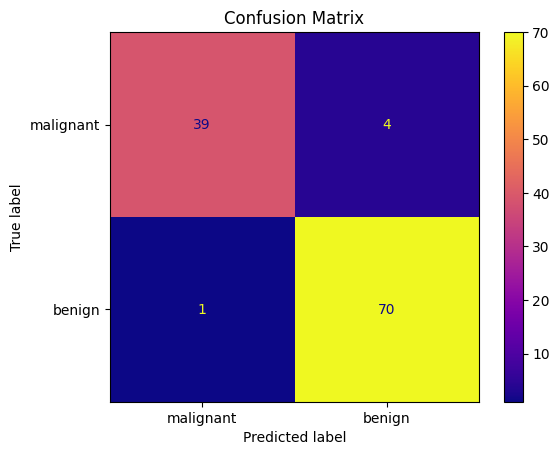


SVM (rbf) Metrics:
Accuracy: 0.95
Precision: 0.92
Recall: 1.00
F1 Score: 0.96
ROC AUC: 0.99


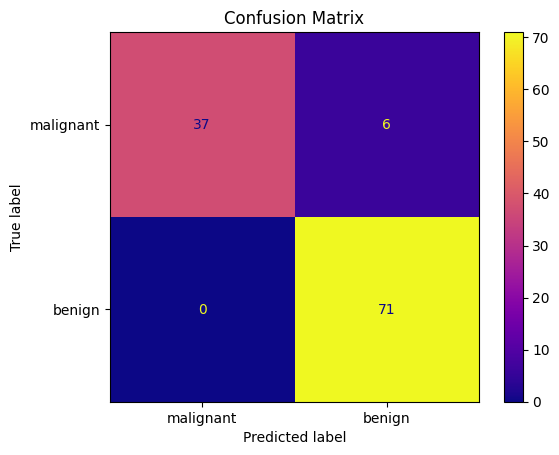

In [62]:
for kernel in ['linear', 'rbf']:
  model_svm = SVC(kernel=kernel, probability=True, random_state=42).fit(X_train, y_train)
  y_pred_svm = model_svm.predict(X_test)
  print(f"\nSVM ({kernel}) Metrics:")
  print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
  print(f"Precision: {precision_score(y_test, y_pred_svm):.2f}")
  print(f"Recall: {recall_score(y_test, y_pred_svm):.2f}")
  print(f"F1 Score: {f1_score(y_test,y_pred_svm):.2f}")
  print(f"ROC AUC: {roc_auc_score(y_test,model_svm.predict_proba(X_test)[:, 1]):.2f}")

  cm = confusion_matrix(y_test, y_pred_svm)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
  disp.plot(cmap=plt.cm.plasma)
  plt.title("Confusion Matrix")
  plt.show()

In [63]:
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

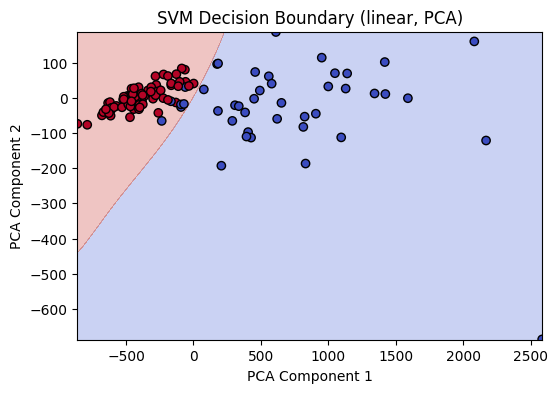

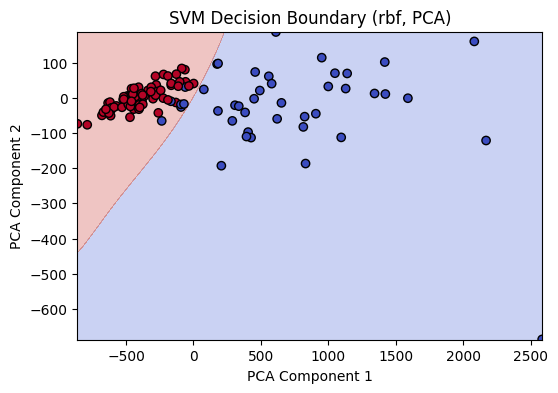

In [65]:
for kernel in ['linear', 'rbf']:

  model_svm_pca = SVC(kernel=kernal).fit(X_train_pca, y_train)

  x_min, x_max = X_test_pca[:, 0].min() - 1,X_test_pca[:, 0].max() + 1
  y_min, y_max = X_test_pca[:, 1].min() - 1,X_test_pca[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.3), np.arange(y_min, y_max, 0.3))
  Z = model_svm_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  plt.figure(figsize=(6,4))
  plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
  plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm',edgecolors='k')
  plt.title(f"SVM Decision Boundary ({kernel}, PCA)")
  plt.xlabel("PCA Component 1")
  plt.ylabel("PCA Component 2")
  plt.show()

In [66]:
for C in [0.1, 1, 10]:
  model_svm = SVC(kernel='rbf', C=C, probability=True, random_state=42).fit(X_train, y_train)
  y_pred_svm = model_svm.predict(X_test)
  print(f"SVM (RBF, C={C}) Metrics:")
  print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}, F1: {f1_score(y_test, y_pred_svm):.2f}")

SVM (RBF, C=0.1) Metrics:
Accuracy: 0.94, F1: 0.95
SVM (RBF, C=1) Metrics:
Accuracy: 0.95, F1: 0.96
SVM (RBF, C=10) Metrics:
Accuracy: 0.95, F1: 0.96


In [67]:
#Task 2D: Decision Trees

In [68]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
print("\nTree Depth:",model_dt.get_depth())
print("Feature Importance:", pd.Series(model_dt.feature_importances_, index=X.columns))


Tree Depth: 7
Feature Importance: mean radius                0.000000
mean texture               0.058478
mean perimeter             0.000000
mean area                  0.000000
mean smoothness            0.000000
mean compactness           0.000000
mean concavity             0.000000
mean concave points        0.691420
mean symmetry              0.000000
mean fractal dimension     0.000000
radius error               0.000000
texture error              0.000000
perimeter error            0.000000
area error                 0.011983
smoothness error           0.001237
compactness error          0.000000
concavity error            0.006276
concave points error       0.015931
symmetry error             0.000000
fractal dimension error    0.018554
worst radius               0.052299
worst texture              0.017445
worst perimeter            0.051494
worst area                 0.000000
worst smoothness           0.009233
worst compactness          0.000000
worst concavity            0.

In [69]:
y_pred_dt = model_dt.predict(X_test)
print("\nDecision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.2f}")
print(f"F1 Score: {f1_score(y_test,y_pred_dt):.2f}")
print(f"ROC AUC: {roc_auc_score(y_test,model_dt.predict_proba(X_test)[:, 1]):.2f}")


Decision Tree Metrics:
Accuracy: 0.95
Precision: 0.96
Recall: 0.96
F1 Score: 0.96
ROC AUC: 0.94


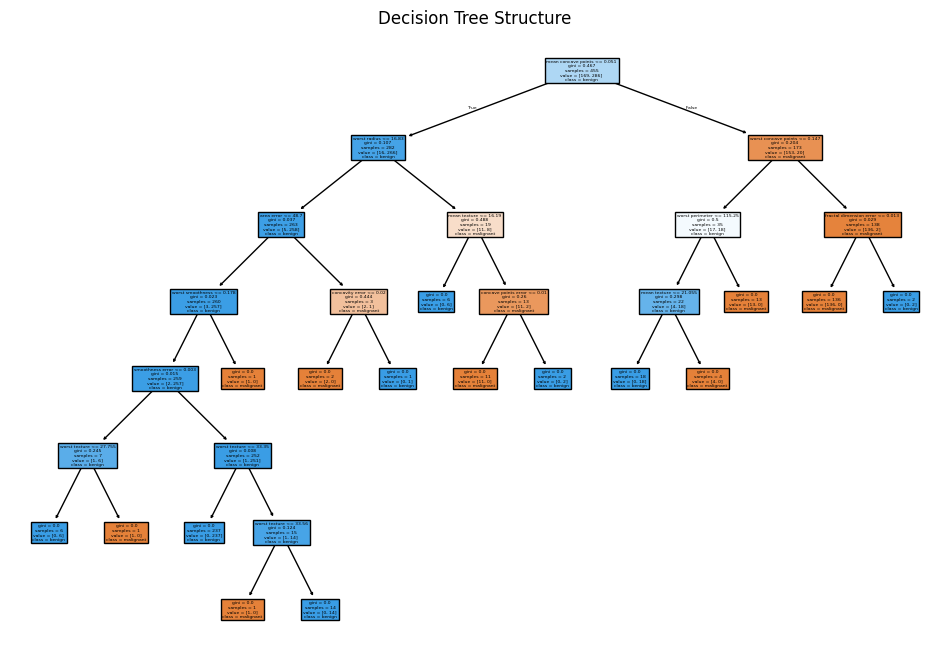

In [70]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model_dt,feature_names=X.columns,
          class_names=['malignant', 'benign'],filled=True)
plt.title("Decision Tree Structure")
plt.show()

In [71]:
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [72]:
model_dt_pca =DecisionTreeClassifier(random_state=42).fit(X_train_pca, y_train)

In [73]:
x_min, x_max = X_test_pca[:, 0].min() - 1,X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1,X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.3), np.arange(y_min, y_max, 0.3))
Z = model_dt_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

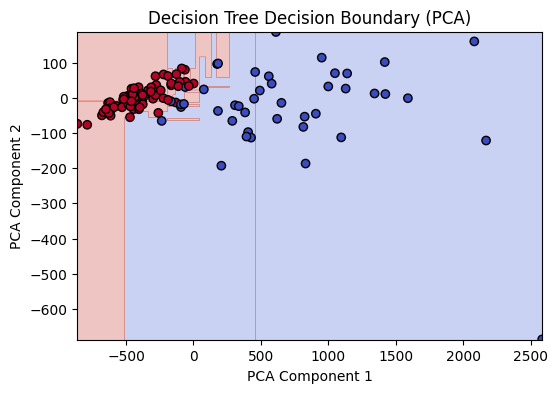

In [74]:
plt.figure(figsize=(6,4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm',edgecolors='k')
plt.title("Decision Tree Decision Boundary (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

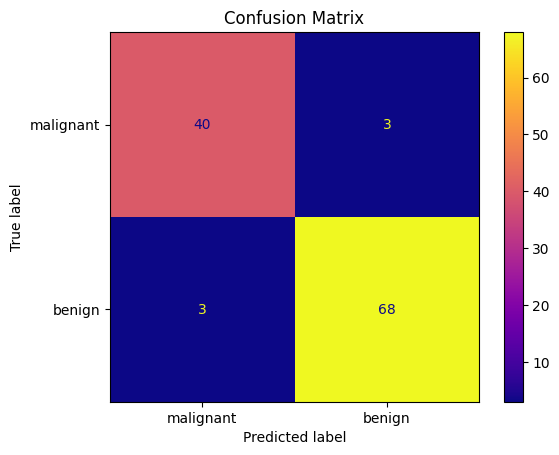

In [75]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion Matrix")
plt.show()

In [76]:
for depth in [1, 3, 10]:
  model_dt = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
  y_pred_dt = model_dt.predict(X_test)
  print(f"Decision Tree (max_depth={depth}) Metrics:")
  print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}, F1: {f1_score(y_test, y_pred_dt):.2f}")

Decision Tree (max_depth=1) Metrics:
Accuracy: 0.89, F1: 0.91
Decision Tree (max_depth=3) Metrics:
Accuracy: 0.95, F1: 0.96
Decision Tree (max_depth=10) Metrics:
Accuracy: 0.95, F1: 0.96
